In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr


import warnings
warnings.filterwarnings('ignore')

In [37]:
df_orig = pd.read_csv("all_rescoring_results_merged.csv")

In [38]:
agg_rules = {
    'CNNscore': 'max',
    'CNNaffinity': 'max',
    'smina_affinity': 'max',
    'RTMScore': 'max',
    'SCORCH': 'max',
    'HYDE': 'max',
    'rfscore_v2': 'max', # Assuming rfscores are probabilities/pKd
    'CHEMPLP': 'min',    # Energy/Fitness (lower is better)
    'vina_hydrophobic': 'min',
    'vina_intra_hydrophobic': 'min',
    'true_value': 'first',     # Metadata, just keep the first instance
    'activity_class': 'first'  # Metadata
}

In [39]:
for col in df_orig.select_dtypes(include=np.number).columns:
    if col not in agg_rules and col not in ["pose", "id", "true_value", "activity_class"]:
        agg_rules[col] = "mean"

df_agg = df_orig.groupby(["id","docking_tool"]).agg(agg_rules).reset_index()
df_agg

,id,docking_tool,CNNscore,CNNaffinity,smina_affinity,RTMScore,SCORCH,HYDE,rfscore_v2,CHEMPLP,vina_hydrophobic,vina_intra_hydrophobic,true_value,activity_class
0,CHEMBL107472,diffdock,0.230358,6.062439,33.47919,11.618160,0.04137,3.918863e+04,7.660917,-62.3337,18.348301,15.424397,5.124939,0
1,CHEMBL107472,flexx,0.318374,6.330606,-2.46342,13.547171,0.06252,3.320067e+06,7.201444,-65.6345,15.781255,14.392877,5.124939,0
2,CHEMBL107472,gnina,0.704503,6.770721,-6.03760,12.169230,0.02622,9.802433e+07,7.196673,-64.3299,17.040275,13.122920,5.124939,0
3,CHEMBL107472,plants,0.845547,6.856157,-5.27772,13.324981,0.03738,5.168395e+08,7.241228,-66.9302,11.281798,13.801589,5.124939,0
4,CHEMBL107472,smina,0.704503,6.770721,-4.72643,11.826247,0.02340,2.193333e+08,7.196673,-64.3299,12.811730,13.769564,5.124939,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,CHEMBL94066,diffdock,0.893995,6.202911,20.50666,15.025520,0.10402,1.003236e+08,7.676534,-59.7566,0.000000,8.434640,6.970616,0
978,CHEMBL94066,flexx,0.198605,6.358852,-5.56480,18.270774,0.01938,1.774943e+02,7.639270,-76.7664,33.518236,7.081279,6.970616,0
979,CHEMBL94066,gnina,0.716842,7.049554,-7.76319,18.041452,0.01837,1.890802e+06,7.603361,-73.0323,38.451399,7.094481,6.970616,0
980,CHEMBL94066,plants,0.598020,7.218567,-4.77817,18.291593,0.01466,1.755772e+07,7.800518,-81.7120,33.279364,7.358269,6.970616,0


In [40]:
meta_cols = ["true_value", "activity_class"]
score_cols = [c for c in df_agg.columns if c not in meta_cols and c not in ["id","docking_tool"]]
wide = df_agg.set_index(["id", "docking_tool"])[score_cols].unstack("docking_tool")
wide.columns = [f"{tool}_{score}" for score, tool in wide.columns]


meta = df_agg.groupby("id")[meta_cols].first()
df_matrix = wide.join(meta)

df_matrix


,diffdock_CNNscore,flexx_CNNscore,gnina_CNNscore,plants_CNNscore,smina_CNNscore,diffdock_CNNaffinity,flexx_CNNaffinity,gnina_CNNaffinity,plants_CNNaffinity,smina_CNNaffinity,...,gnina_vina_hydrophobic,plants_vina_hydrophobic,smina_vina_hydrophobic,diffdock_vina_intra_hydrophobic,flexx_vina_intra_hydrophobic,gnina_vina_intra_hydrophobic,plants_vina_intra_hydrophobic,smina_vina_intra_hydrophobic,true_value,activity_class
id,,,,,,,,,,,,,,,,,,,,,
CHEMBL107472,0.230358,0.318374,0.704503,0.845547,0.704503,6.062439,6.330606,6.770721,6.856157,6.770721,...,17.040275,11.281798,12.811730,15.424397,14.392877,13.122920,13.801589,13.769564,5.124939,0
CHEMBL1090364,0.753230,0.459508,0.648672,0.085986,0.648672,8.145165,7.744378,8.244999,7.844476,8.086423,...,33.329206,46.584723,35.004347,17.199321,11.857168,10.846852,18.751411,10.846852,8.193820,1
CHEMBL1095464,NaN,0.221300,0.949931,0.441181,0.949931,NaN,6.349084,7.639035,7.255926,7.639035,...,40.377515,34.069408,40.377515,NaN,15.048121,13.751400,19.417773,13.751400,5.040959,0
CHEMBL1097189,0.299841,0.733825,0.841830,0.811187,0.841830,6.579234,7.683257,7.730244,7.670531,7.730244,...,51.521676,59.248934,51.521676,23.898682,39.983632,26.721804,37.518372,26.721804,5.602060,0
CHEMBL1172773,0.113217,0.049243,0.592747,0.601510,0.593319,6.965350,6.588732,7.554906,7.454876,7.557323,...,55.350394,57.858481,47.827333,40.425779,42.480121,35.049914,33.861991,32.076141,7.086186,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL7819,0.317333,0.552823,0.818149,0.798095,0.818149,5.896833,6.073943,6.436514,6.395360,6.436514,...,32.888089,31.902450,28.105821,9.504977,8.492893,8.704411,8.681227,8.685322,6.769551,0
CHEMBL7866,0.484698,0.612489,0.917534,0.849771,0.917534,6.512511,6.415994,6.857832,6.744023,6.857832,...,26.546878,27.433593,26.546878,9.510094,8.346990,8.686770,8.681995,8.686770,7.193820,0
CHEMBL80540,0.286375,0.438205,0.840270,0.359730,0.840270,6.106951,6.671166,7.850224,7.350696,7.850224,...,34.297352,30.289108,45.067768,12.714972,9.648312,9.131143,9.301261,9.120654,8.522879,1


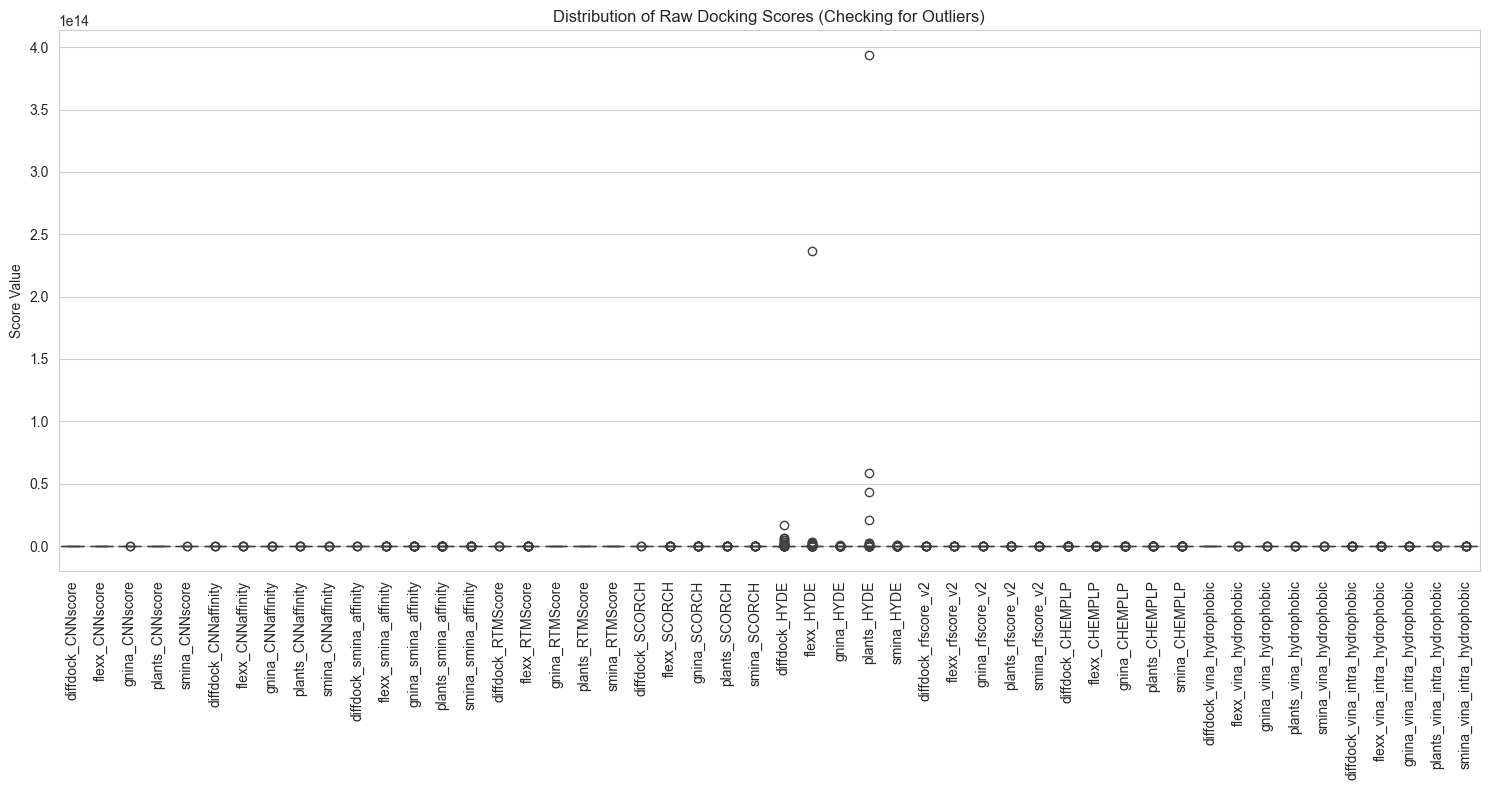

In [41]:
feature_cols = [col for col in df_matrix.columns if col not in meta_cols]
plt.figure(figsize=(15,8))
sns.boxplot(data=df_matrix[feature_cols])
plt.xticks(rotation=90)
plt.title("Distribution of Raw Docking Scores (Checking for Outliers)")
plt.ylabel("Score Value")
plt.tight_layout()
plt.show()

In [42]:
df_matrix["plants_HYDE"].max(), df_matrix["plants_HYDE"].min(), df_matrix["plants_HYDE"].mean()


(np.float64(393737554462321.7),
 np.float64(91079.970987),
 np.float64(2726921102452.317))

In [43]:

# # Assuming 'df_matrix' is your unstacked dataframe from earlier
# feature_cols = [c for c in df_matrix.columns if c not in ["true_value", "activity_class"]]

# # Create a copy so we don't mess up the original
# df_clean = df_matrix.copy()

# # --- STEP 1: WORST-CASE IMPUTATION ---
# for col in feature_cols:
#     if df_clean[col].isna().any():
#         # Check if this is a 'min' or 'max' metric based on your agg_rules
#         base_metric = col.split('_', 1)[1] # e.g., gets 'CHEMPLP' from 'diffdock_CHEMPLP'
        
#         # If it's an energy score (lower is better), the "worst" is a high positive number
#         if base_metric in ['CHEMPLP', 'vina_hydrophobic', 'vina_intra_hydrophobic']:
#             worst_val = df_clean[col].max()
#             penalty = worst_val + (abs(worst_val) * 0.1) # Make it 10% worse
#         # If it's an affinity/probability score (higher is better), the "worst" is a low number
#         else:
#             worst_val = df_clean[col].min()
#             penalty = worst_val - (abs(worst_val) * 0.1) # Make it 10% worse
            
#         df_clean[col].fillna(penalty, inplace=True)

# # --- STEP 2: IQR CLIPPING (Targeted Outlier Removal) ---
# for col in feature_cols:
#     Q1 = df_clean[col].quantile(0.25)
#     Q3 = df_clean[col].quantile(0.75)
#     IQR = Q3 - Q1
    
#     # 3x IQR is a standard threshold for "extreme" outliers
#     lower_bound = Q1 - 3 * IQR
#     upper_bound = Q3 + 3 * IQR
    
#     df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# # --- STEP 3: ROBUST SCALING ---
# scaler = RobustScaler()
# df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

# print("Imputation, Clipping, and Scaling Complete!")

In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1. DROP NaNs
df_clean = df_matrix.dropna().copy()

print(f"Rows remaining after dropping NaNs: {len(df_clean)}")
feature_cols = [c for c in df_clean.columns if c not in ["true_value", "activity_class"]]
clipping_stats = []

# 2. IQR CLIPPING (To handle HYDE outliers)
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    if outliers_count > 0:
        clipping_stats.append({'Feature': col, 'Values_Squashed': outliers_count})
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# 3. ROBUST SCALING
scaler = RobustScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])
df_squashed = pd.DataFrame(clipping_stats).sort_values(by='Values_Squashed', ascending=False)
print("Number of extreme values squashed:")
print(df_squashed)

Rows remaining after dropping NaNs: 179
Number of extreme values squashed:
                            Feature  Values_Squashed
11                       flexx_HYDE               33
10                    diffdock_HYDE               32
14                       smina_HYDE               31
12                       gnina_HYDE               25
13                      plants_HYDE               24
2             plants_smina_affinity               19
23                   plants_CHEMPLP               17
24                    smina_CHEMPLP               17
20                 diffdock_CHEMPLP               16
22                    gnina_CHEMPLP               13
21                    flexx_CHEMPLP               12
9                      smina_SCORCH                6
7                      gnina_SCORCH                6
3              smina_smina_affinity                5
8                     plants_SCORCH                5
6                      flexx_SCORCH                5
27     flexx_vina_intra_

In [45]:
df_clean.isna().any().unique()

array([False])

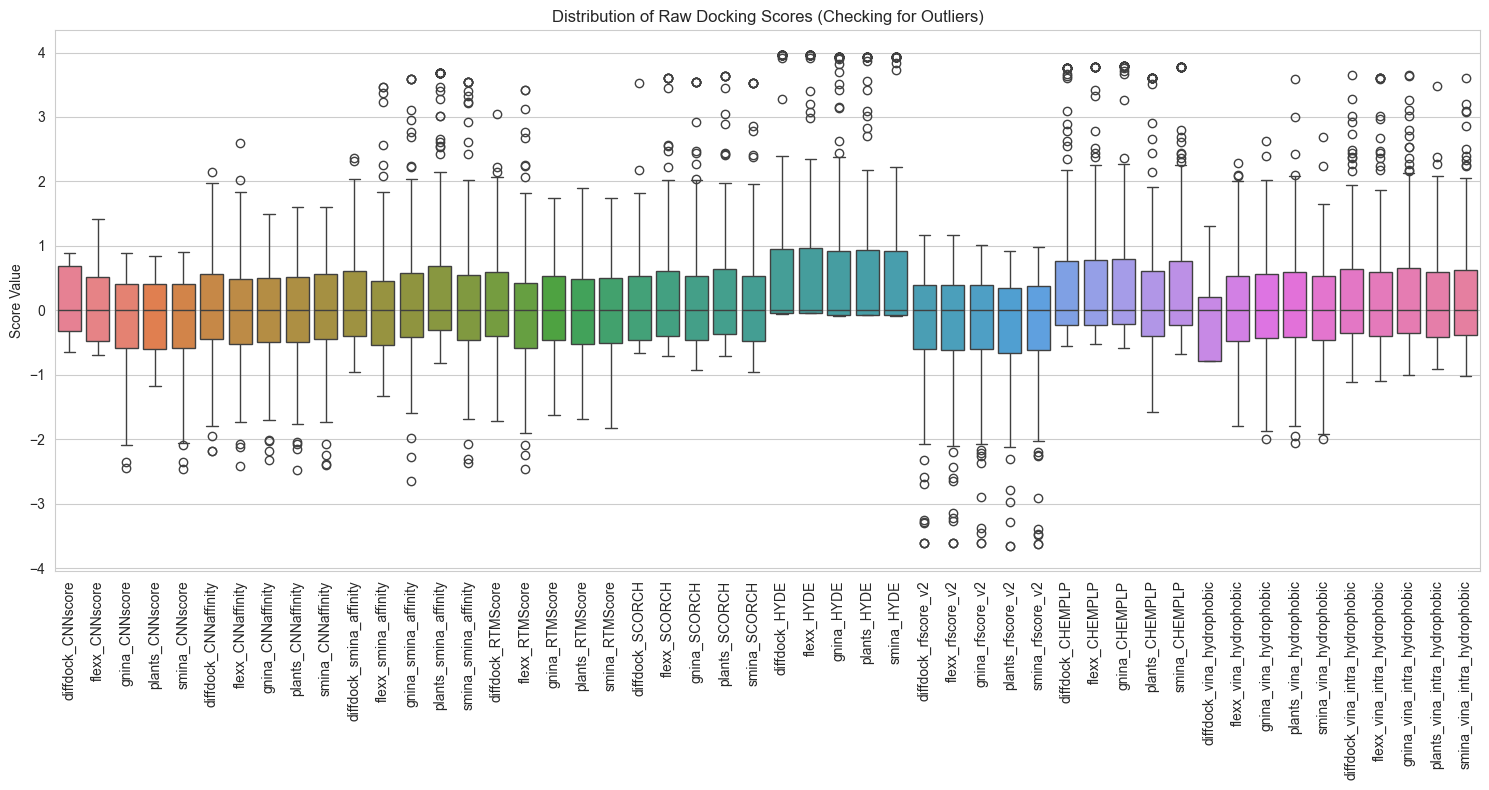

In [46]:
feature_cols = [col for col in df_clean.columns if col not in meta_cols]
plt.figure(figsize=(15,8))
sns.boxplot(data=df_clean[feature_cols])
plt.xticks(rotation=90)
plt.title("Distribution of Raw Docking Scores (Checking for Outliers)")
plt.ylabel("Score Value")
plt.tight_layout()
plt.show()

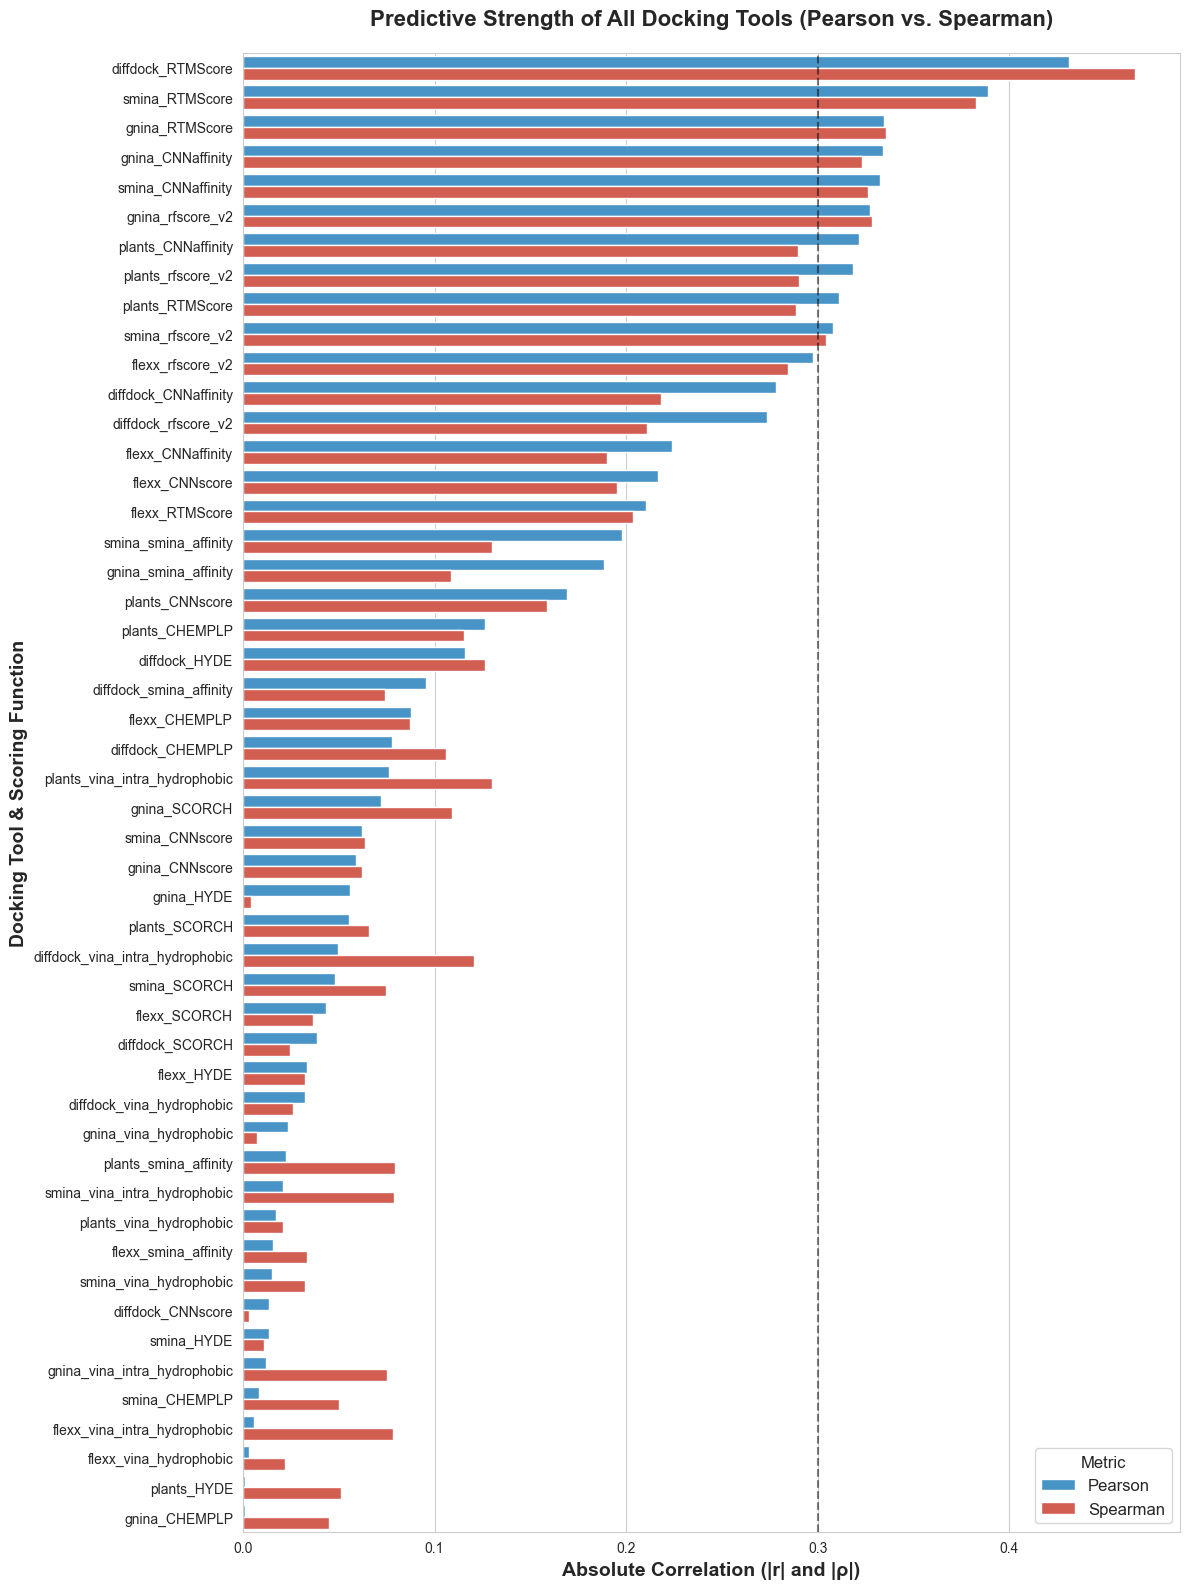

In [ ]:


# 1. Calculate Correlations for all features
corr_data = []
for col in feature_cols:
    p_corr, _ = pearsonr(df_clean[col], df_clean['true_value'])
    s_corr, _ = spearmanr(df_clean[col], df_clean['true_value'])
    corr_data.append({
        'Feature': col,
        'Pearson': abs(p_corr),   
        'Spearman': abs(s_corr)
    })

# Convert to DataFrame and sort by the strongest Pearson score
df_corr = pd.DataFrame(corr_data).sort_values(by='Pearson', ascending=False)

# 2. Reshape data for Seaborn (Melt)
df_melted = df_corr.melt(id_vars='Feature', 
                         var_name='Correlation Type', 
                         value_name='Absolute Correlation')

# 3. Create the Visualization
plt.figure(figsize=(12, 16))
sns.set_style("whitegrid")

# Draw the grouped bar chart
ax = sns.barplot(data=df_melted, 
                 y='Feature', 
                 x='Absolute Correlation', 
                 hue='Correlation Type', 
                 palette=['#3498db', '#e74c3c']) 

# Formatting
plt.title("Predictive Strength of All Docking Tools (Pearson vs. Spearman)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Absolute Correlation (|r| and |ρ|)", fontsize=14, fontweight='bold')
plt.ylabel("Docking Tool & Scoring Function", fontsize=14, fontweight='bold')
plt.legend(title='Metric', fontsize=12, title_fontsize=12, loc='lower right')

# Add a vertical threshold line at 0.3
plt.axvline(x=0.3, color='black', linestyle='--', alpha=0.5, label='Moderate Signal Threshold')

plt.tight_layout()
plt.savefig("Full_Feature_Correlation_Analysis.png", dpi=300)
plt.show()

In [48]:
# 1. Start fresh from the dropped NaNs
df_ml = df_matrix.dropna().copy()

# 2. Define X and y, and SPLIT FIRST (Zero Data Leakage)
X = df_ml[feature_cols].copy()
y = df_ml['true_value'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Strict IQR Clipping (Learn bounds from Train, apply to both)
for col in feature_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

# 4. Strict Quantile Transformation (Learn shape from Train, apply to both)
qt = QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=100)
X_train[feature_cols] = qt.fit_transform(X_train[feature_cols])
X_test[feature_cols] = qt.transform(X_test[feature_cols])

In [49]:
_cost = {
    "localdiffdock": 407.5, "diffdock": 407.5, "flexx": 3.33, "smina": 99.9,
    "gnina": 105.8, "plants": 6.85, "cnnscore": 0.31, "cnnaffinity": 0.31,
    "smina_affinity": 0.31, "ad4": 0.28, "linf9": 0.24, "rtmscore": 0.41,
    "vinardo": 0.29, "scorch": 4.63, "hyde": 2.0, "chemplp": 0.121,
    "rfscore_v1": 0.682, "rfscore_v2": 0.687, "rfscore_v3": 0.69,
    "vina_hydrophobic": 0.69, "vina_intra_hydrophobic": 0.69,
}

for col in feature_cols:
    parts = col.split('_', 1) 
    tool_cost = _cost.get(parts[0].lower(), 0.0)
    score_cost = _cost.get(parts[1].lower(), 0.0) if len(parts) > 1 else 0.0
    total_cost = tool_cost + score_cost if (tool_cost + score_cost) > 0 else 1.0
    
    X_train[col] = X_train[col] / total_cost
    X_test[col] = X_test[col] / total_cost

# 6. Train and Evaluate ML Model (e.g., Lasso)
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)
print(f"🎯 STRICT PIPELINE LASSO R-SQUARED: {r2_score(y_test, y_pred):.4f}")

🎯 STRICT PIPELINE LASSO R-SQUARED: -0.0899


In [50]:
# from sklearn.linear_model import Lasso
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score

# # 1. Prepare our X (Features) and y (Target)
# X = df_clean[feature_cols].copy()
# y = df_clean['true_value']

# # 2. Define the exact costs (make sure names match your columns)
# # Note: I'm mapping your original _cost dictionary to our new column names
# cost_dict = {
#     "localdiffdock": 407.5, "diffdock": 407.5, "flexx": 3.33, "smina": 99.9,
#     "gnina": 105.8, "plants": 6.85, "cnnscore": 0.31, "cnnaffinity": 0.31,
#     "smina_affinity": 0.31, "ad4": 0.28, "linf9": 0.24, "rtmscore": 0.41,
#     "vinardo": 0.29, "scorch": 4.63, "hyde": 2.0, "chemplp": 0.121,
#     "rfscore_v1": 0.682, "rfscore_v2": 0.687, "rfscore_v3": 0.69,
#     "vina_hydrophobic": 0.69, "vina_intra_hydrophobic": 0.69
# }

# # Apply the mathematical trick: Divide each column by its tool's cost
# for col in X.columns:
#     tool_name = col.split('_')[0] # Extracts 'diffdock' from 'diffdock_CNNscore'
#     # We add a tiny number (0.01) to avoid dividing by zero if a cost is missing
#     cost = cost_dict.get(tool_name.lower(), 1.0) 
#     X[col] = X[col] / cost

# # 3. Split data into Train and Test sets (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 4. Initialize and Train the Lasso Model
# # alpha is our penalty strength. We start with a small penalty.
# lasso_model = Lasso(alpha=0.09, random_state=42)
# lasso_model.fit(X_train, y_train)

# # 5. Evaluate the Model
# y_pred = lasso_model.predict(X_test)
# print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
# print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}\n")
# # 6. See which algorithms survived the Cost Pruning!
# weights = pd.DataFrame({
#     'Feature': feature_cols,
#     'Weight': lasso_model.coef_
# })

# # Sort by absolute weight to see the most important features
# weights['Abs_Weight'] = weights['Weight'].abs()
# survivors = weights[weights['Abs_Weight'] > 0].sort_values(by='Abs_Weight', ascending=False)

# print(f"Total features originally: {len(feature_cols)}")
# print(f"Features kept by Cost-Weighted Lasso: {len(survivors)}")
# print("\nThe Pareto Optimal Pipeline Tools (Surviving Features):")
# print(survivors[['Feature', 'Weight']])

In [51]:


print(f"\nDataset Size: {len(X)} molecules | Features: {len(feature_cols)}")

# ==========================================
# TEST 1: THE NON-LINEARITY CHECK
# ==========================================
print("\n--- TEST 1: FEATURE CORRELATION (LINEAR VS. RANK) ---")
# If Spearman is significantly higher than Pearson for top features, we have non-linear relationships.
corr_data = []
for col in feature_cols:
    p_corr, _ = pearsonr(X[col], y)
    s_corr, _ = spearmanr(X[col], y)
    corr_data.append({
        'Feature': col, 
        'Pearson (Linear)': abs(p_corr), 
        'Spearman (Rank)': abs(s_corr),
        'Difference': abs(abs(s_corr) - abs(p_corr))
    })

df_corr = pd.DataFrame(corr_data).sort_values(by='Pearson (Linear)', ascending=False).head(5)
print("Top 5 Features by Linear Correlation:")
print(df_corr.to_string(index=False))

rf = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_leaf=4, random_state=42)
rf.fit(X_train, y_train)
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("\nNon-Linear (Constrained Random Forest):")
print(f"  -> Train R2: {r2_score(y_train, rf_train_pred):.4f}")
print(f"  -> Test R2:  {r2_score(y_test, rf_test_pred):.4f}")

rf_importances = pd.DataFrame({'Feature': feature_cols, 'Importance': rf.feature_importances_})
top_rf = rf_importances.sort_values(by='Importance', ascending=False).head(5)['Feature'].tolist()

print("\nTop 5 Features (Random Forest - Non-Linear/Interactions):")
for f in top_rf: print(f" - {f}")



Dataset Size: 179 molecules | Features: 50

--- TEST 1: FEATURE CORRELATION (LINEAR VS. RANK) ---
Top 5 Features by Linear Correlation:
          Feature  Pearson (Linear)  Spearman (Rank)  Difference
diffdock_RTMScore          0.431085         0.465790    0.034705
   smina_RTMScore          0.388653         0.382361    0.006292
   gnina_RTMScore          0.334682         0.335848    0.001167
gnina_CNNaffinity          0.333997         0.323116    0.010880
 gnina_rfscore_v2          0.333636         0.328608    0.005029

Non-Linear (Constrained Random Forest):
  -> Train R2: 0.6726
  -> Test R2:  0.3560

Top 5 Features (Random Forest - Non-Linear/Interactions):
 - diffdock_RTMScore
 - diffdock_CNNaffinity
 - gnina_vina_hydrophobic
 - flexx_SCORCH
 - smina_vina_hydrophobic


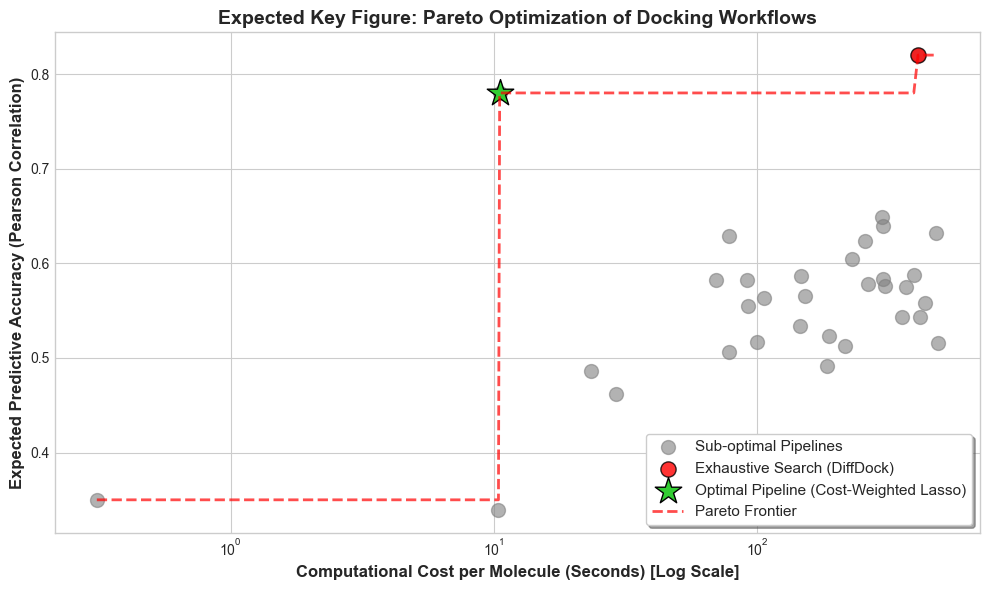

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate Theoretical "Expected" Data
np.random.seed(42)
costs = np.random.uniform(0.1, 500, 30)
accuracies = 0.8 - (0.5 / (np.log10(costs + 1.1))) + np.random.normal(0, 0.05, 30)
accuracies = np.clip(accuracies, 0.2, 0.85)

# Add your specific tools as anchor points
costs = np.append(costs, [407.5, 0.31, 10.5])
accuracies = np.append(accuracies, [0.82, 0.35, 0.78]) # DiffDock, CNNscore, Our Optimal Pipeline

# 2. Setup the Plot
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot all background pipelines
plt.scatter(costs, accuracies, color='grey', alpha=0.6, s=100, label="Sub-optimal Pipelines")

# Plot the expensive baseline
plt.scatter(407.5, 0.82, color='red', alpha=0.8, s=120, edgecolors='black', label="Exhaustive Search (DiffDock)")

# Plot your goal
plt.scatter(10.5, 0.78, color='limegreen', marker='*', s=400, edgecolors='black', label="Optimal Pipeline (Cost-Weighted Lasso)")

# 3. Draw the Pareto Frontier boundary
sorted_indices = np.argsort(costs)
c_sorted = costs[sorted_indices]
a_sorted = accuracies[sorted_indices]
pareto_front = np.maximum.accumulate(a_sorted)
plt.plot(c_sorted, pareto_front, color='red', linestyle='--', linewidth=2, alpha=0.7, label="Pareto Frontier")

# 4. Formatting
plt.xscale('log') 
plt.xlabel("Computational Cost per Molecule (Seconds) [Log Scale]", fontsize=12, fontweight='bold')
plt.ylabel("Expected Predictive Accuracy (Pearson Correlation)", fontsize=12, fontweight='bold')
plt.title("Expected Key Figure: Pareto Optimization of Docking Workflows", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

# 5. Save it to your computer!
plt.tight_layout()
plt.savefig("Expected_Key_Figure_Mockup.png", dpi=300)
plt.show()